In [255]:
import numpy as np
import pandas as pd

In [256]:
df=pd.read_csv('/kaggle/input/datasets/rtx123gforce/placement-data/placement.csv')

In [257]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [258]:
df=df.iloc[:,1:]

In [259]:
df


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [260]:
df.shape

(100, 3)

In [261]:
type(df.isnull())

pandas.core.frame.DataFrame

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [263]:
import matplotlib.pyplot as plt

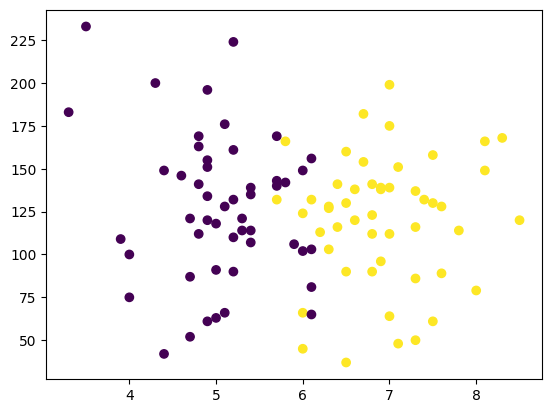

In [264]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [265]:
X=df.iloc[:,0:2]

In [266]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [267]:
y=df.iloc[:,-1]
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [268]:
from sklearn.model_selection import train_test_split

In [269]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.1)

In [270]:
X_train

,cgpa,iq
0,6.8,123.0
77,7.3,50.0
43,6.8,141.0
71,6.1,132.0
81,5.4,107.0
...,...,...
52,7.0,175.0
74,6.7,154.0
66,6.9,96.0
32,7.0,139.0


In [271]:
from sklearn.preprocessing import StandardScaler

In [272]:
Scaler=StandardScaler()

In [273]:
X_train=Scaler.fit_transform(X_train)

In [274]:
X_train

array([[ 0.72064815,  0.00855051],
       [ 1.17293778, -1.80360652],
       [ 0.72064815,  0.45538375],
       [ 0.08744266,  0.23196713],
       [-0.54576282, -0.38863459],
       [ 0.901564  , -1.45606955],
       [ 0.26835851, -0.48793087],
       [ 0.72064815, -0.26451425],
       [-0.00301526,  0.6539763 ],
       [ 0.44927437,  0.182319  ],
       [ 0.99202193, -1.85325466],
       [ 0.26835851,  0.13267086],
       [-0.54576282,  0.30643934],
       [ 1.89660119,  1.07598548],
       [-0.90759453, -0.78581969],
       [-0.8171366 ,  1.32422617],
       [-1.08851038, -0.26451425],
       [-0.99805245,  1.82070754],
       [ 1.17293778, -0.16521797],
       [-0.99805245, -0.06592169],
       [-0.99805245,  0.80292072],
       [-0.90759453, -1.48089362],
       [ 0.901564  ,  1.89517975],
       [ 1.62522741, -0.21486611],
       [ 2.2584329 , -0.06592169],
       [ 0.35881644,  0.45538375],
       [-0.00301526, -1.92772686],
       [ 1.35385363, -1.53054176],
       [-1.08851038,

In [275]:
X_test=Scaler.transform(X_test)

In [276]:
from sklearn.linear_model import LogisticRegression

In [277]:
clf=LogisticRegression()


In [278]:
clf.fit(X_train,y_train)

LogisticRegression()

In [279]:
y_pred=clf.predict(X_test)

In [280]:
y_pred

array([1, 1, 1, 0, 0, 1, 0, 0, 0, 1])

In [281]:
y_test

56    0
27    1
37    1
39    0
75    0
38    1
4     0
23    0
31    0
53    1
Name: placement, dtype: int64

In [282]:
from sklearn.metrics import accuracy_score

In [283]:
accuracy_score(y_test,y_pred)

0.9

In [284]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

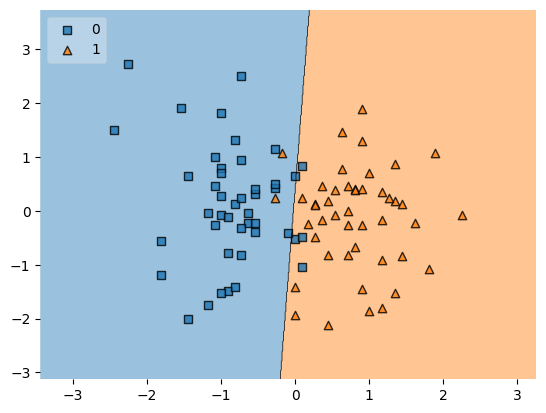

In [285]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [286]:
import pickle

In [287]:
pickle.dump(clf,open('model.pkl','wb'))